# Explore here

In [17]:
import pandas as pd

url = 'https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv'

data = pd.read_csv(url)

data.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [18]:
data['date'] = pd.to_datetime(data.date)
data = data.set_index('date')

st = data['sales']
st.head()

date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64

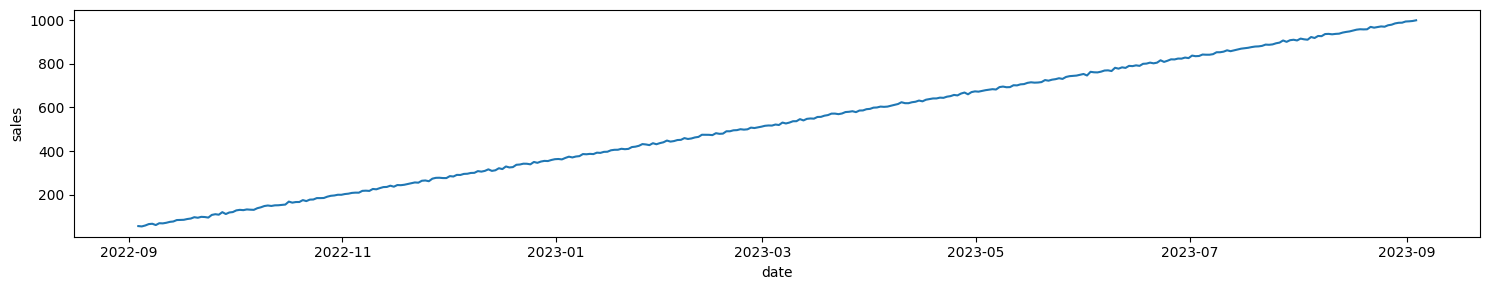

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(figsize = (15, 3))

sns.lineplot(data = st)

plt.tight_layout()

plt.show()

In [20]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(st)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(st)
decomposition

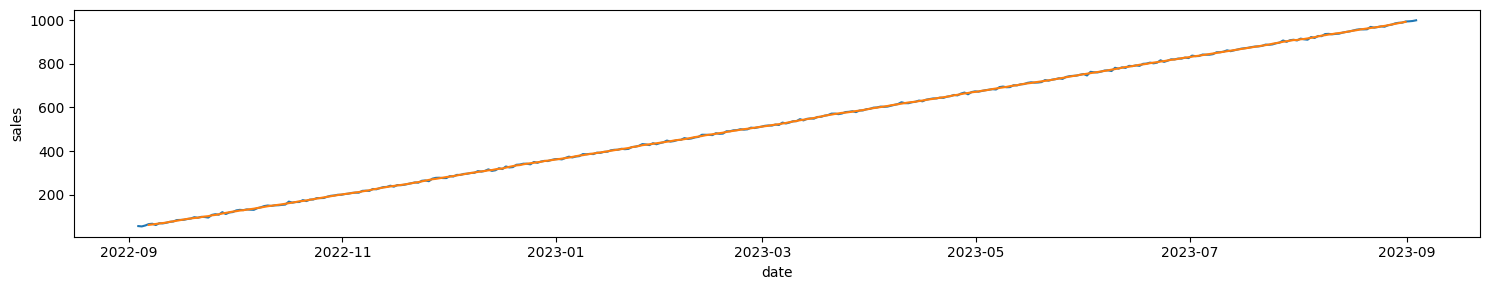

In [22]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (15, 3))

sns.lineplot(data = st)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

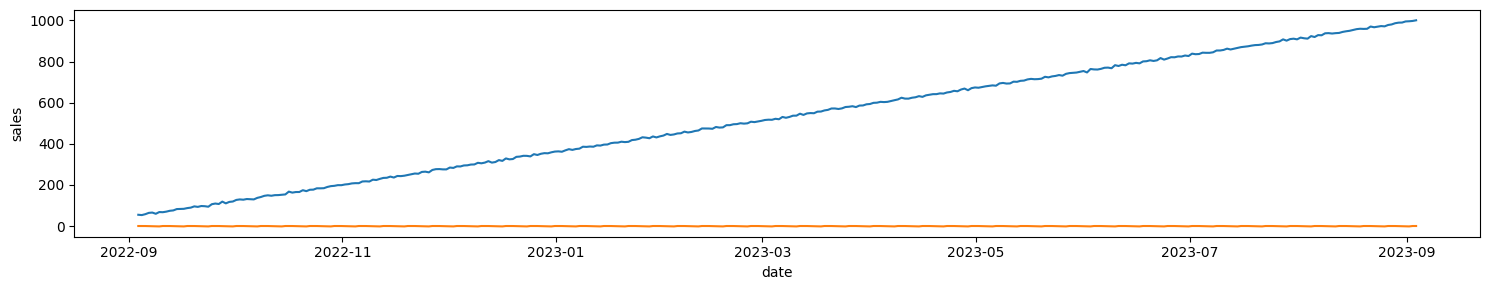

In [23]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (15, 3))

sns.lineplot(data = st)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

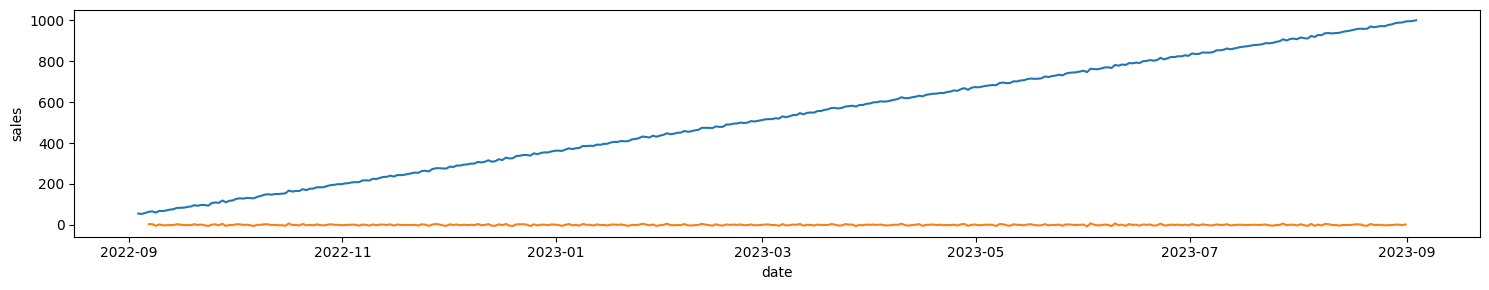

In [24]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (15, 3))

sns.lineplot(data = st)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

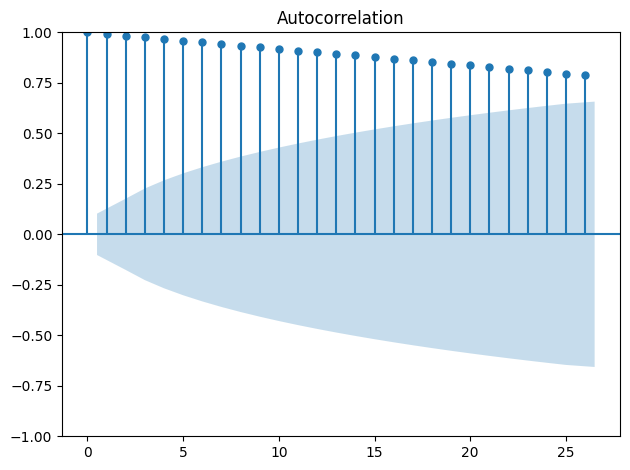

In [25]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(st)

plt.tight_layout()

plt.show()

In [26]:
st_estac = st.diff().dropna()

test_stationarity(st_estac)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

In [27]:
from pmdarima import auto_arima

model = auto_arima(st_estac, seasonal = False, trace = True, m = 7)

Performing stepwise search to minimize aic


/home/vscode/.local/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (7) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed

 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.39 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2205.881, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2208.143, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2176.042, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=2112.720, Time=0.03 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=2078.913, Time=0.04 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.

 ARIMA(5,0,0)(0,0,0)[0]             : AIC=2042.352, Time=0.07 sec


...

 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=1891.197, Time=0.61 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=1910.621, Time=0.07 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.61 sec


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=1867.276, Time=0.73 sec

Best model:  ARIMA(4,0,1)(0,0,0)[0] intercept
Total fit time: 5.779 seconds


In [28]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(4, 0, 1)   Log Likelihood                -914.561
Date:                Mon, 14 Apr 2025   AIC                           1843.122
Time:                        03:43:47   BIC                           1870.421
Sample:                    09-04-2022   HQIC                          1853.971
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.0597      0.397      7.708      0.000       2.282       3.838
ar.L1         -0.0980      0.054     -1.798      0.072      -0.205       0.009
ar.L2         -0.0098      0.065     -0.150      0.881      -0.137       0.118
ar.L3          0.0113      0.061      0.183      0.854      -0.109       0.132
ar.L4         -0.0813      0.056     -1.459      0.145      -0.191       0.028
ma.L1         -0.9274      0.028    -33.604      0.000      -0.981      -0.873
sigma2         8.8324      0.716     12.337      0.000       7.429      10.236
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.21
Prob(Q):                              0.99   Prob(JB):                         0.55
Heteroskedasticity (H):               0.94   Skew:                             0.08
Prob(H) (two-sided):                  0.72   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [30]:
forecast = model.predict(60)
forecast

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2023-09-04 17:10:08.079328    1.485894
2023-09-05 17:10:08.079328    2.833586
2023-09-06 17:10:08.079328    2.678053
2023-09-07 17:10:08.079328    2.531735
2023-09-08 17:10:08.079328    2.696651
2023-09-09 17:10:08.079328    2.570607
2023-09-10 17:10:08.079328    2.592337
2023-09-11 17:10:08.079328    2.605195
2023-09-12 17:10:08.079328    2.588895
2023-09-13 17:10:08.079328    2.600858
2023-09-14 17:10:08.079328    2.598224
2023-09-15 17:10:08.079328    2.597136
2023-09-16 17:10:08.079328    2.598728
2023-09-17 17:10:08.079328    2.597581
2023-09-18 17:10:08.079328    2.597879
2023-09-19 17:10:08.079328    2.597968
2023-09-20 17:10:08.079328    2.597814
2023-09-21 17:10:08.079328    2.597925
2023-09-22 17:10:08.079328    2.597892
2023-09-23 17:10:08.079328    2.597885
2023-09-24 17:10:08.079328    2.597900
2023-09-25 17:10:08.079328    2.597889
2023-09-26 17:10:08.079328    2.597893
2023-09-27 17:10:08.079328    2.597893
2023-09-28 17:10:08.079328    2.597892
2023-09-29 17:10:08.07932

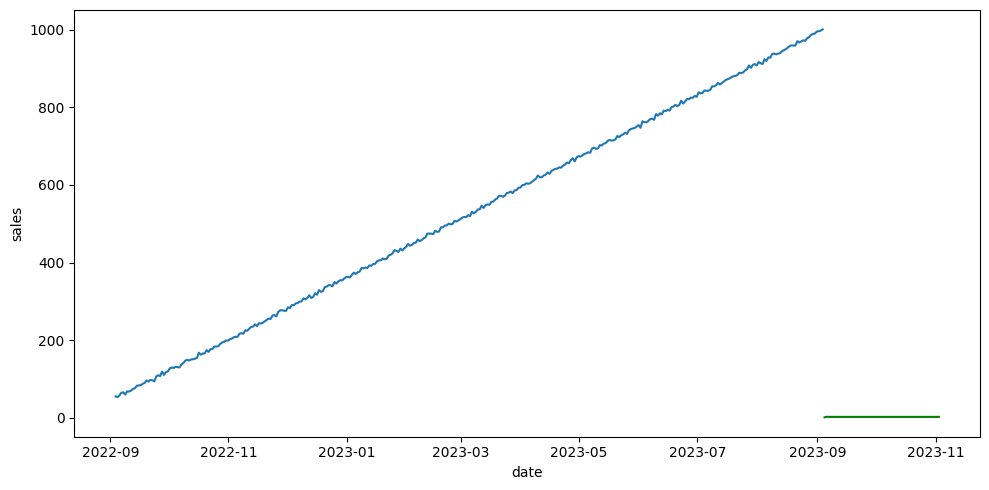

In [32]:

import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = st)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()